In [1]:
import pandas as pd
import numpy as np

In [2]:
_df = pd.read_excel('iris.data1.xlsx')

In [3]:
_df.head()

,5.1,3.5,1.4,0.2,Iris-setosa
0,4.9,3.0,1.4,0.2,Iris-setosa
1,4.7,3.2,1.3,0.2,Iris-setosa
2,4.6,3.1,1.5,0.2,Iris-setosa
3,5.0,3.6,1.4,0.2,Iris-setosa
4,5.4,3.9,1.7,0.4,Iris-setosa


In [4]:
# Shape of dataset
print('Shape of Dataset:', _df.shape)


Shape of Dataset: (149, 5)


In [5]:
# Display columns
print('\nColumns in Dataset:')
print(_df.columns)


Columns in Dataset:
Index([5.1, 3.5, 1.4, 0.2, 'Iris-setosa'], dtype='object')


In [6]:
# Information about dataset
print('\nDataset Information:')
print(_df.info())


Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 149 entries, 0 to 148
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   5.1          149 non-null    float64
 1   3.5          149 non-null    float64
 2   1.4          149 non-null    float64
 3   0.2          149 non-null    float64
 4   Iris-setosa  149 non-null    object 
dtypes: float64(4), object(1)
memory usage: 5.9+ KB
None


In [7]:
print('\nStatistical Summary:')
print(_df.describe())


Statistical Summary:
              5.1         3.5         1.4         0.2
count  149.000000  149.000000  149.000000  149.000000
mean     5.848322    3.051007    3.774497    1.205369
std      0.828594    0.433499    1.759651    0.761292
min      4.300000    2.000000    1.000000    0.100000
25%      5.100000    2.800000    1.600000    0.300000
50%      5.800000    3.000000    4.400000    1.300000
75%      6.400000    3.300000    5.100000    1.800000
max      7.900000    4.400000    6.900000    2.500000


In [8]:
# Count missing values in each column
print(_df.isnull().sum())

5.1            0
3.5            0
1.4            0
0.2            0
Iris-setosa    0
dtype: int64


In [9]:
# Drop missing values
_df = _df.dropna()

In [10]:
# Check again
print(_df.isnull().sum())

5.1            0
3.5            0
1.4            0
0.2            0
Iris-setosa    0
dtype: int64


In [11]:
# Count duplicate rows
print('Duplicate Rows:', _df.duplicated().sum())

Duplicate Rows: 3


In [12]:

# Remove duplicates
_df = _df.drop_duplicates()


In [15]:

# RENAMING COLUMNS FOR BETTER UNDERSTANDING
_df.columns = ['Sepal_Length','Sepal_Width','Petal_Length','Petal_Width','Species']



In [16]:
print(_df.dtypes)

Sepal_Length    float64
Sepal_Width     float64
Petal_Length    float64
Petal_Width     float64
Species          object
dtype: object


In [17]:
# Convert numeric columns into float
_df['Sepal_Length'] = _df['Sepal_Length'].astype(float)
_df['Sepal_Width'] = _df['Sepal_Width'].astype(float)
_df['Petal_Length'] = _df['Petal_Length'].astype(float)
_df['Petal_Width'] = _df['Petal_Width'].astype(float)

print(_df.dtypes)

Sepal_Length    float64
Sepal_Width     float64
Petal_Length    float64
Petal_Width     float64
Species          object
dtype: object


In [18]:
print(_df['Species'].unique())

['Iris-setosa' 'Iris-versicolor' 'Iris-virginica']


In [19]:

# Select numerical columns
numerical_columns = [
    'Sepal_Length',
    'Sepal_Width',
    'Petal_Length',
    'Petal_Width'
]

# Loop through columns
for column in numerical_columns:
    
    Q1 = _df[column].quantile(0.25)
    Q3 = _df[column].quantile(0.75)
    IQR = Q3 - Q1

    lower_limit = Q1 - 1.5 * IQR
    upper_limit = Q3 + 1.5 * IQR

    outliers = _df[(
        (_df[column] < lower_limit) |
        (_df[column] > upper_limit)
    )]

    print(f'Outliers in {column}:', len(outliers))

Outliers in Sepal_Length: 0
Outliers in Sepal_Width: 4
Outliers in Petal_Length: 0
Outliers in Petal_Width: 0


In [20]:
# REMOVING OUTLIERS USING IQR METHOD

for column in numerical_columns:

    Q1 = _df[column].quantile(0.25)
    Q3 = _df[column].quantile(0.75)
    IQR = Q3 - Q1

    lower_limit = Q1 - 1.5 * IQR
    upper_limit = Q3 + 1.5 * IQR

    _df = _df[(
        (_df[column] >= lower_limit) &
        (_df[column] <= upper_limit)
    )]

In [21]:
# SAVING CLEANED DATASET
_df.to_csv('cleaned_iris_dataset.csv', index=False)
print('Cleaned dataset saved successfully!')

Cleaned dataset saved successfully!


In [22]:
_df.head()

,Sepal_Length,Sepal_Width,Petal_Length,Petal_Width,Species
0,4.9,3.0,1.4,0.2,Iris-setosa
1,4.7,3.2,1.3,0.2,Iris-setosa
2,4.6,3.1,1.5,0.2,Iris-setosa
3,5.0,3.6,1.4,0.2,Iris-setosa
4,5.4,3.9,1.7,0.4,Iris-setosa


In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [24]:
# LOADING CLEANED DATASET
_df = pd.read_csv('cleaned_iris_dataset.csv')

# Display first 5 rows
print(_df.head())

   Sepal_Length  Sepal_Width  Petal_Length  Petal_Width      Species
0           4.9          3.0           1.4          0.2  Iris-setosa
1           4.7          3.2           1.3          0.2  Iris-setosa
2           4.6          3.1           1.5          0.2  Iris-setosa
3           5.0          3.6           1.4          0.2  Iris-setosa
4           5.4          3.9           1.7          0.4  Iris-setosa


In [25]:
print(_df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 142 entries, 0 to 141
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Sepal_Length  142 non-null    float64
 1   Sepal_Width   142 non-null    float64
 2   Petal_Length  142 non-null    float64
 3   Petal_Width   142 non-null    float64
 4   Species       142 non-null    object 
dtypes: float64(4), object(1)
memory usage: 5.7+ KB
None


In [26]:
print("Shape of Dataset:", _df.shape)

Shape of Dataset: (142, 5)


In [27]:
print("Duplicate Rows:", _df.duplicated().sum())

Duplicate Rows: 0


In [28]:

print(_df['Species'].unique())

['Iris-setosa' 'Iris-versicolor' 'Iris-virginica']


In [29]:
# CORRELATION MATRIX
correlation = _df.corr(numeric_only=True)

print(correlation)

TypeError: corr() got an unexpected keyword argument 'numeric_only'

In [30]:
# CORRELATION MATRIX
# Selecting only numerical columns
numerical_data = _df.select_dtypes(include=['float64', 'int64'])

# Calculate correlation matrix
correlation = numerical_data.corr()

# Display correlation matrix
print(correlation)

              Sepal_Length  Sepal_Width  Petal_Length  Petal_Width
Sepal_Length      1.000000    -0.106511      0.878594     0.820689
Sepal_Width      -0.106511     1.000000     -0.389647    -0.320522
Petal_Length      0.878594    -0.389647      1.000000     0.960252
Petal_Width       0.820689    -0.320522      0.960252     1.000000


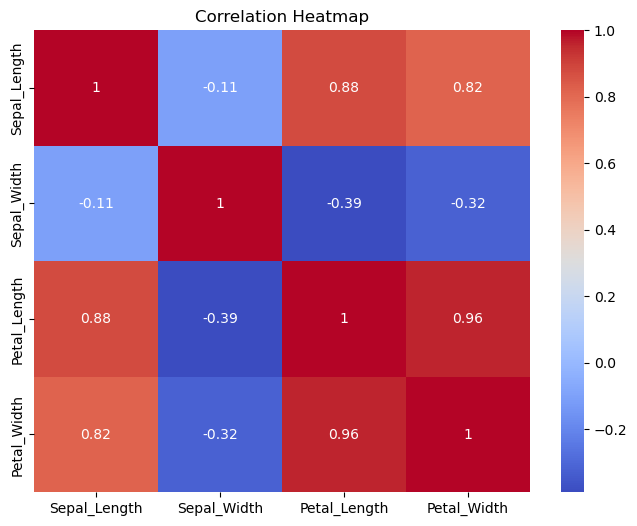

In [31]:
# HEATMAP VISUALIZATION
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,6))

sns.heatmap(
    correlation,
    annot=True,
    cmap='coolwarm'
)

plt.title('Correlation Heatmap')

plt.show()

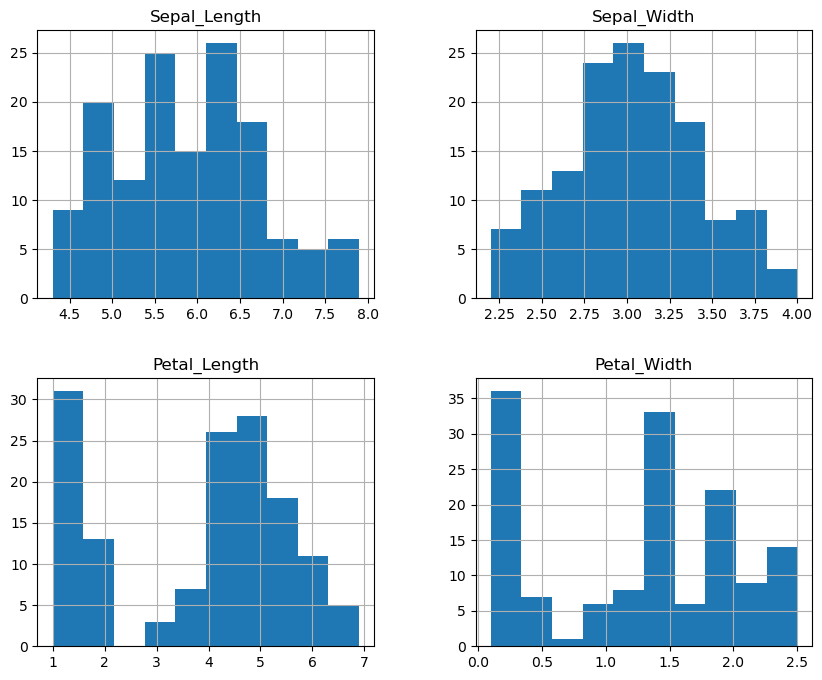

In [32]:
# HISTOGRAMS OF FEATURES
_df.hist(figsize=(10,8))

plt.show()

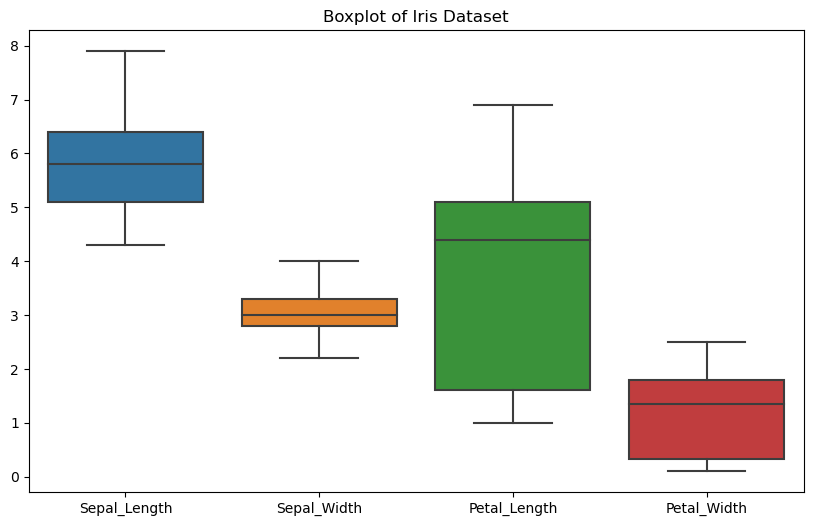

In [33]:
# BOXPLOT FOR OUTLIER DETECTION
# #############################################################

plt.figure(figsize=(10,6))

sns.boxplot(data=_df)

plt.title('Boxplot of Iris Dataset')

plt.show()

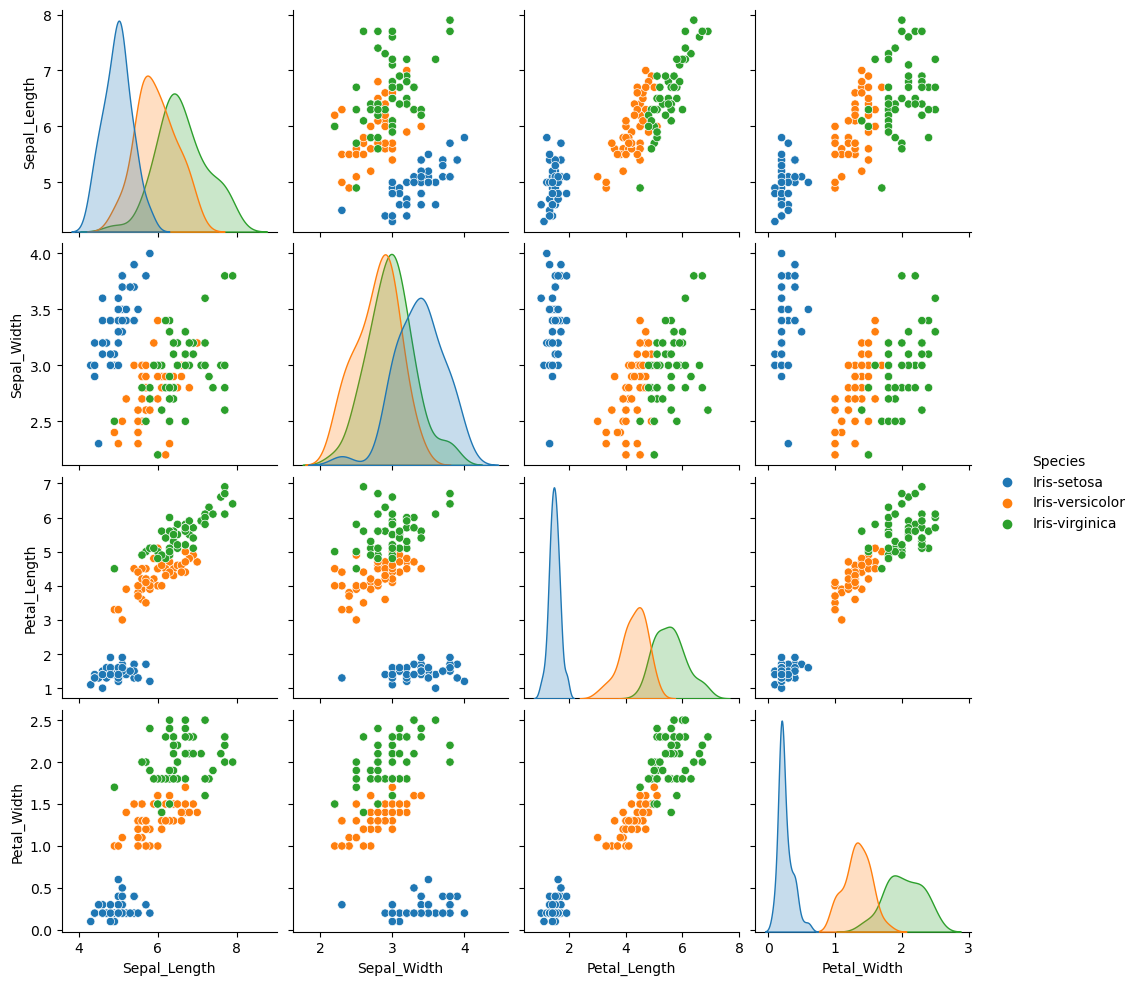

In [34]:
# PAIRPLOT OF FEATURES
# #############################################################

sns.pairplot(
    _df,
    hue='Species'
)

plt.show()

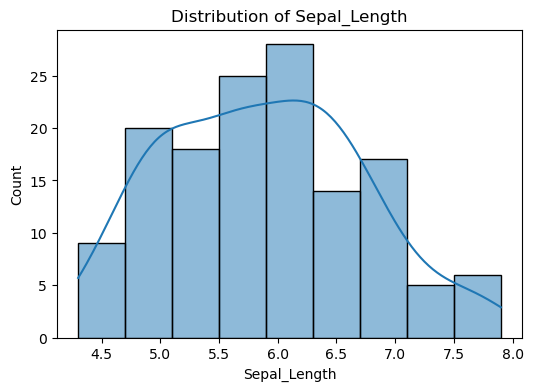

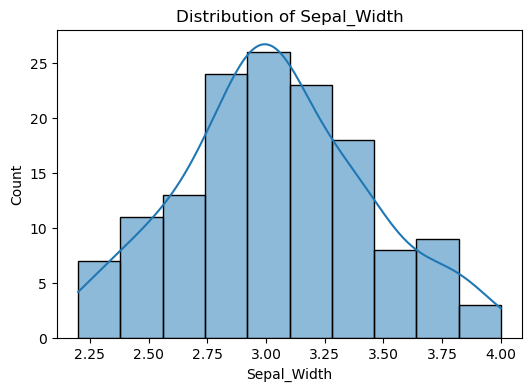

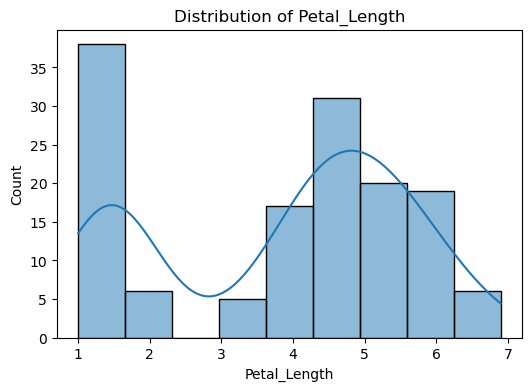

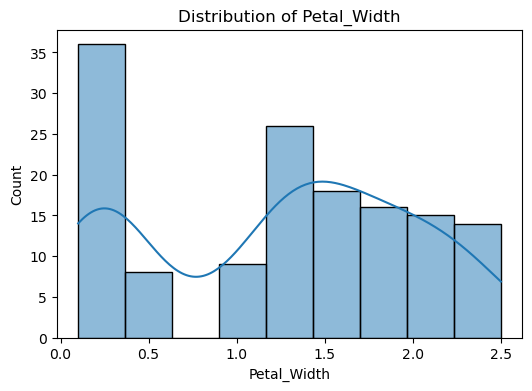

In [35]:
# DISTRIBUTION PLOT OF FEATURES
# #############################################################

for column in _df.columns[:-1]:

    plt.figure(figsize=(6,4))

    sns.histplot(
        _df[column],
        kde=True
    )

    plt.title(f'Distribution of {column}')

    plt.show()

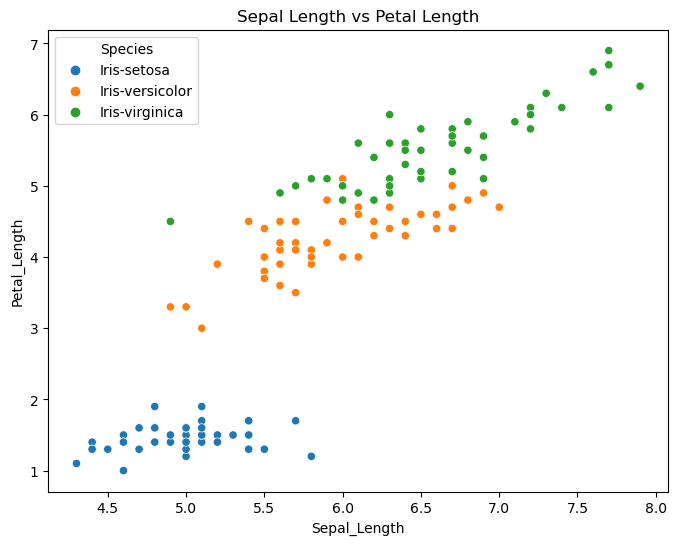

In [36]:
# SCATTER PLOT

plt.figure(figsize=(8,6))

sns.scatterplot(
    x='Sepal_Length',
    y='Petal_Length',
    hue='Species',
    data=_df
)

plt.title('Sepal Length vs Petal Length')

plt.show()

In [37]:
# CHECKING KURTOSIS
print(_df.kurt(numeric_only=True))

Sepal_Length   -0.587900
Sepal_Width    -0.251056
Petal_Length   -1.303105
Petal_Width    -1.274939
dtype: float64


In [38]:
# SPECIES-WISE MEAN VALUES
print(_df.groupby('Species').mean())

                 Sepal_Length  Sepal_Width  Petal_Length  Petal_Width
Species                                                              
Iris-setosa          4.977273     3.375000      1.463636     0.252273
Iris-versicolor      5.955102     2.785714      4.275510     1.332653
Iris-virginica       6.604082     2.979592      5.561224     2.028571


In [39]:

_df.to_csv('EDA_Iris_Dataset.csv', index=False)

print("EDA Dataset Saved Successfully!")

EDA Dataset Saved Successfully!


In [40]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split

from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree

from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

import matplotlib.pyplot as plt

In [51]:
# LOADING CLEANED DATASET


_df = pd.read_csv('cleaned_iris_dataset.csv')

# Display first 5 rows
print(_df.head())

   Sepal_Length  Sepal_Width  Petal_Length  Petal_Width      Species
0           4.9          3.0           1.4          0.2  Iris-setosa
1           4.7          3.2           1.3          0.2  Iris-setosa
2           4.6          3.1           1.5          0.2  Iris-setosa
3           5.0          3.6           1.4          0.2  Iris-setosa
4           5.4          3.9           1.7          0.4  Iris-setosa


In [52]:
# DISPLAYING DATASET INFORMATION

print(_df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 142 entries, 0 to 141
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Sepal_Length  142 non-null    float64
 1   Sepal_Width   142 non-null    float64
 2   Petal_Length  142 non-null    float64
 3   Petal_Width   142 non-null    float64
 4   Species       142 non-null    object 
dtypes: float64(4), object(1)
memory usage: 5.7+ KB
None


In [43]:
# DEFINING FEATURES AND TARGET VARIABLE
# Features
X = _df.drop('Species', axis=1)

# Target Variable
y = _df['Species']

# Display Shapes
print("Shape of X:", X.shape)
print("Shape of y:", y.shape)

Shape of X: (142, 4)
Shape of y: (142,)


In [44]:
# SPLITTING DATASET
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Display Shapes
print("Training Data Shape:", X_train.shape)
print("Testing Data Shape:", X_test.shape)

Training Data Shape: (113, 4)
Testing Data Shape: (29, 4)


In [45]:
# CREATING DECISION TREE MODEL
decision_tree = DecisionTreeClassifier(
    criterion='gini',
    max_depth=3,
    random_state=42
)

# Train Model
decision_tree.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=3, random_state=42)

In [46]:
y_pred = decision_tree.predict(X_test)

# Display Predictions
print(y_pred)

['Iris-versicolor' 'Iris-setosa' 'Iris-versicolor' 'Iris-virginica'
 'Iris-versicolor' 'Iris-setosa' 'Iris-virginica' 'Iris-versicolor'
 'Iris-versicolor' 'Iris-setosa' 'Iris-versicolor' 'Iris-versicolor'
 'Iris-virginica' 'Iris-virginica' 'Iris-virginica' 'Iris-versicolor'
 'Iris-setosa' 'Iris-versicolor' 'Iris-virginica' 'Iris-versicolor'
 'Iris-setosa' 'Iris-virginica' 'Iris-virginica' 'Iris-versicolor'
 'Iris-versicolor' 'Iris-versicolor' 'Iris-setosa' 'Iris-setosa'
 'Iris-setosa']


In [47]:
# CALCULATING ACCURACY
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy of Decision Tree Model:", accuracy)

Accuracy of Decision Tree Model: 0.9310344827586207


In [48]:
# CONFUSION MATRIX
cm = confusion_matrix(y_test, y_pred)

print(cm)

# CLASSIFICATION REPORT
report = classification_report(y_test, y_pred)

print(report)


[[ 8  0  0]
 [ 0 11  0]
 [ 0  2  8]]
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00         8
Iris-versicolor       0.85      1.00      0.92        11
 Iris-virginica       1.00      0.80      0.89        10

       accuracy                           0.93        29
      macro avg       0.95      0.93      0.94        29
   weighted avg       0.94      0.93      0.93        29



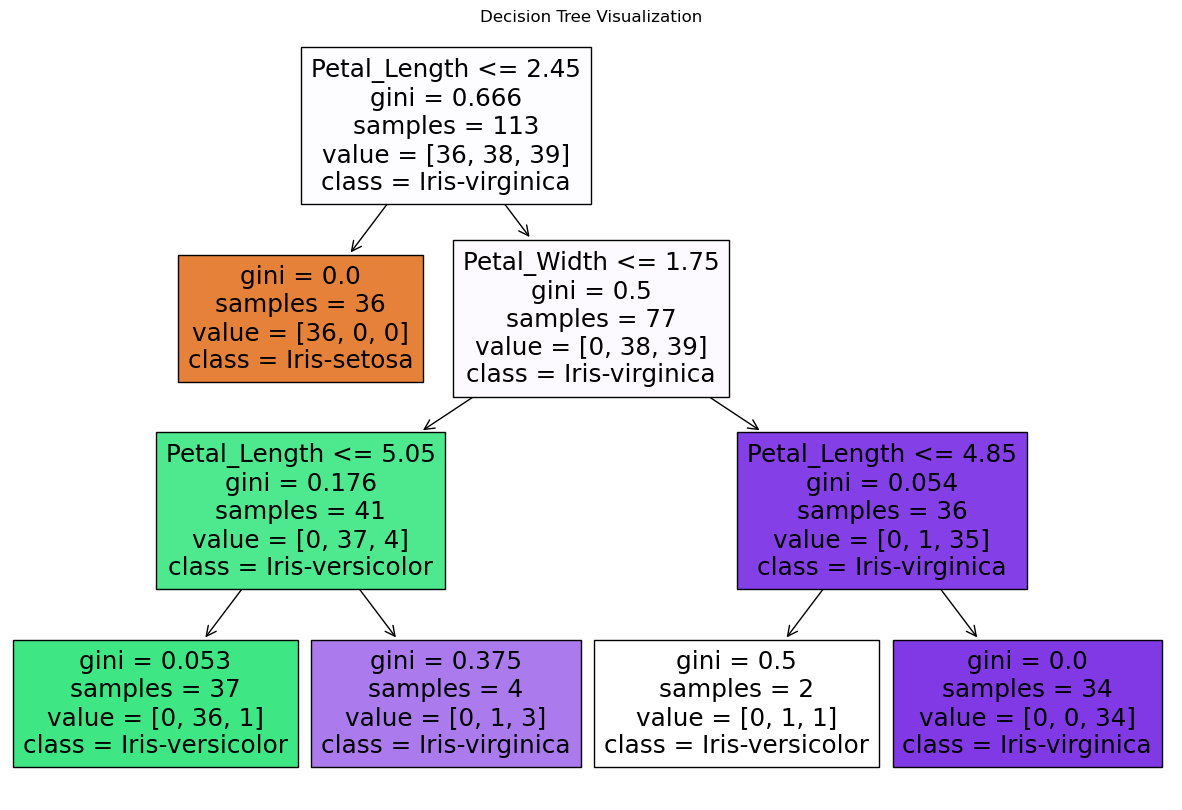

In [49]:
# VISUALIZING DECISION TREE
plt.figure(figsize=(15,10))

plot_tree(
    decision_tree,
    feature_names=X.columns,
    class_names=decision_tree.classes_,
    filled=True
)

plt.title("Decision Tree Visualization")

plt.show()

In [50]:
# FEATURE IMPORTANCE
importance = decision_tree.feature_importances_

# Create DataFrame
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importance
})

# Sort Values
feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

print(feature_importance)

        Feature  Importance
2  Petal_Length     0.58601
3   Petal_Width     0.41399
0  Sepal_Length     0.00000
1   Sepal_Width     0.00000
